In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [20]:
data_dir = r"C:\Users\Admin\DL\dataset-resized"

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1,
    horizontal_flip=True,
    vertical_flip=True
)
test = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1
)

In [22]:
train_generator = train.flow_from_directory(
    directory=data_dir,
    target_size=(224,224),
    class_mode="categorical",
    subset="training"
)

test_generator = test.flow_from_directory(
    directory=data_dir,
    target_size=(224,224),
    class_mode="categorical",
    subset="validation"
)

Found 2276 images belonging to 6 classes.
Found 251 images belonging to 6 classes.


In [23]:
import tensorflow as tf
from tensorflow import keras
input_tensor = tf.random.normal([1, 224, 224, 3])
conv_layer = keras.layers.Conv2D(
    filters=32,
    kernel_size=3,
    padding='same',
    activation='relu'
)
output_tensor = conv_layer(input_tensor)
print("Input Shape :", input_tensor.shape)
print("Output Shape:", output_tensor.shape)

Input Shape : (1, 224, 224, 3)
Output Shape: (1, 224, 224, 32)


In [24]:
pool_layer = keras.layers.MaxPooling2D(pool_size=2)
pooled_output = pool_layer(output_tensor)
print("Shape before pooling :", output_tensor.shape)
print("Shape after pooling  :", pooled_output.shape)

Shape before pooling : (1, 224, 224, 32)
Shape after pooling  : (1, 112, 112, 32)


Class Names : {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Number of Training Images : 2276
Number of Validation Images : 251
Batch Size : 32
Image Size : (224, 224)


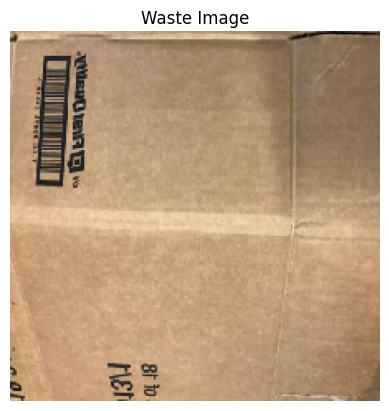

In [25]:
print("Class Names :", train_generator.class_indices)
print("Number of Training Images :", train_generator.samples)
print("Number of Validation Images :", test_generator.samples)
print("Batch Size :", train_generator.batch_size)
print("Image Size :", train_generator.target_size)
import matplotlib.pyplot as plt
images, labels = next(train_generator)
plt.imshow(images[0])
plt.title("Waste Image")
plt.axis("off")
plt.show()

In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
model = keras.Sequential([
    layers.Conv2D(filters=32,
                  kernel_size=3,
                  activation='relu',
                  input_shape=(224,224,3)),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(filters=64,
                  kernel_size=3,
                  activation='relu'),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 186624)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │      11,944,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,963,782 (45.64 MB)

 Trainable params: 11,963,782 (45.64 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
print("Starting CNN Training...")
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)
print("Training Finished.")

Starting CNN Training...
Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 536ms/step - accuracy: 0.2957 - loss: 2.5056 - val_accuracy: 0.3825 - val_loss: 1.4752
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 508ms/step - accuracy: 0.4468 - loss: 1.3698 - val_accuracy: 0.4263 - val_loss: 1.3890
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 534ms/step - accuracy: 0.4917 - loss: 1.2702 - val_accuracy: 0.4582 - val_loss: 1.3130
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 514ms/step - accuracy: 0.5264 - loss: 1.2308 - val_accuracy: 0.4900 - val_loss: 1.2755
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 522ms/step - accuracy: 0.5549 - loss: 1.1465 - val_accuracy: 0.5339 - val_loss: 1.2213
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 519ms/step - accuracy: 0.6072 - loss: 1.0446 - val_accuracy: 0.5179 - val_loss: 1.2037
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 513ms/step - accuracy: 0.6481 - loss: 0.9671 - val_accuracy: 0.5697 - val_loss: 1.1665
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 518ms/step - accuracy: 0.6511 

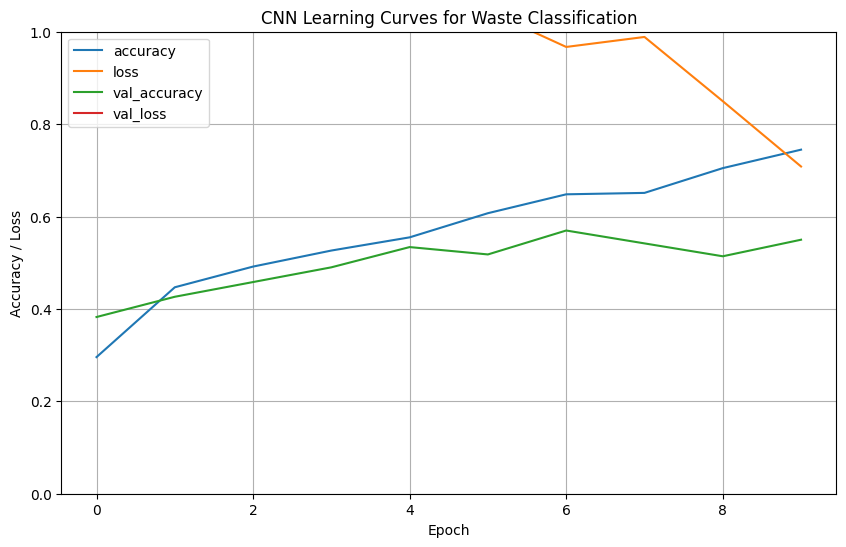

In [28]:
import pandas as pd
history_df = pd.DataFrame(history.history)
history_df.plot(
    figsize=(10,6),
    grid=True,
    title="CNN Learning Curves for Waste Classification",
    ylim=(0,1)
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy / Loss")
plt.show()

In [29]:
from sklearn.metrics import classification_report
loss, accuracy = model.evaluate(test_generator)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())
print("\n--- Classification Report ---\n")
print(classification_report(y_true, y_pred, target_names=class_names))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.5498 - loss: 1.2321
Final Test Accuracy: 54.98%
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step

--- Classification Report ---

              precision    recall  f1-score   support

   cardboard       0.12      0.10      0.11        40
       glass       0.07      0.06      0.07        50
       metal       0.18      0.27      0.22        41
       paper       0.26      0.29      0.27        59
     plastic       0.24      0.17      0.20        48
       trash       0.12      0.15      0.14        13

    accuracy                           0.18       251
   macro avg       0.17      0.17      0.17       251
weighted avg       0.18      0.18      0.17       251

